In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [58]:
clean_data_path = "../data/data_clean.csv"
data_df = pd.read_csv(clean_data_path)

In [59]:
data_df.dtypes


gen                   float64
english_name           object
percent_male          float64
percent_female        float64
height_m              float64
weight_kg             float64
capture_rate          float64
base_egg_steps        float64
hp                    float64
attack                float64
defense               float64
sp_attack             float64
sp_defense            float64
speed                 float64
against_normal        float64
against_fire          float64
against_water         float64
against_electric      float64
against_grass         float64
against_ice           float64
against_fighting      float64
against_poison        float64
against_ground        float64
against_flying        float64
against_psychict      float64
against_bug           float64
against_rock          float64
against_ghost         float64
against_dragon        float64
against_dark          float64
against_steel         float64
against_fairy         float64
votes_first           float64
votes_top_

In [60]:
data_df.describe(include="all")

,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,against_fairy,votes_first,votes_top_6,num_abilities,evo_length,has_mega_evolution,has_gigantamax,rarity,class_primary,class_secondary
count,1024.000000,1024,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.0000,1024.000000,1024.000000,...,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
unique,NaN,1024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Bulbasaur,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.738281,NaN,46.532100,38.233525,1.211035,66.953906,94.976562,7097.5000,70.152344,77.514648,...,1.092773,2.802734,15.544922,2.372070,3.283203,0.044922,0.030273,0.147461,6.318359,4.623047
std,2.632948,NaN,27.153005,24.713124,1.248642,121.331744,76.129587,6810.6675,26.624286,29.815854,...,0.545856,5.924761,27.267545,0.740691,1.584341,0.207234,0.171422,0.533101,4.949621,5.096766
min,1.000000,NaN,0.000000,0.000000,0.100000,0.100000,3.000000,640.0000,1.000000,5.000000,...,0.250000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,NaN,50.000000,11.860000,0.500000,8.500000,45.000000,3840.0000,50.000000,55.000000,...,1.000000,0.000000,2.000000,2.000000,3.000000,0.000000,0.000000,0.000000,2.000000,1.000000
50%,5.000000,NaN,50.200000,49.800000,1.000000,28.000000,60.000000,5120.0000,68.000000,75.000000,...,1.000000,1.000000,6.000000,3.000000,3.000000,0.000000,0.000000,0.000000,5.000000,1.000000
75%,7.000000,NaN,50.200000,50.000000,1.500000,70.000000,140.000000,6400.0000,85.000000,100.000000,...,1.000000,3.000000,15.000000,3.000000,5.000000,0.000000,0.000000,0.000000,10.000000,8.000000


In [61]:
n_primary_classes = data_df["class_primary"].nunique()
n_primary_classes

18

In [62]:
n_secondary_classes = data_df["class_secondary"].nunique()
n_secondary_classes

19


## Univariate z-score anomalies ##

What do these outliers look like?
Why are they different from the rest of the data?


Disregard generations for now. Take only numerical features

In [63]:
# Identify outliers;
# ignore "gen" columns and categorical columns
feature_cols = [col for col in data_df.columns if col not in ["english_name", "class_primary", "class_secondary", "attack"] and not col.startswith("gen")]

# let's use z-score method to identify outliers
from scipy import stats
z_scores = np.abs(stats.zscore(data_df[feature_cols]))
outlier_threshold = 3
outliers = (z_scores > outlier_threshold).any(axis=1)

# sort data by number of outlier features
data_df['num_outlier_features'] = (z_scores > outlier_threshold).sum(axis=1)
data_df_sorted = data_df.sort_values(by='num_outlier_features', ascending=False)

# Count how many outliers were found
num_outliers = outliers.sum()
print(f"Number of outlier samples identified: {num_outliers}")

Number of outlier samples identified: 381


In [64]:
data_df_sorted.head(20)

,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,votes_first,votes_top_6,num_abilities,evo_length,has_mega_evolution,has_gigantamax,rarity,class_primary,class_secondary,num_outlier_features
804,7.0,Stakataka,0.00,0.00,5.5,820.0,30.0,30720.0,61.0,131.0,...,0.0,8.0,1.0,1.0,0.0,0.0,1.0,11,11,6
383,3.0,Rayquaza,0.00,0.00,7.0,206.5,45.0,30720.0,105.0,150.0,...,20.0,156.0,1.0,1.0,1.0,0.0,2.0,14,2,6
142,1.0,Snorlax,88.14,11.86,2.1,460.0,25.0,10240.0,160.0,110.0,...,29.0,98.0,3.0,3.0,0.0,1.0,0.0,4,1,5
798,7.0,Guzzlord,0.00,0.00,5.5,888.0,45.0,30720.0,223.0,101.0,...,0.0,5.0,1.0,1.0,0.0,0.0,1.0,15,15,5
719,6.0,Hoopa,0.00,0.00,0.5,9.0,3.0,30720.0,80.0,110.0,...,1.0,10.0,1.0,1.0,0.0,0.0,3.0,10,16,5
93,1.0,Gengar,50.20,49.80,1.5,40.5,45.0,5120.0,60.0,65.0,...,43.0,216.0,1.0,5.0,1.0,1.0,0.0,12,0,5
486,4.0,Giratina,0.00,0.00,4.5,750.0,3.0,30720.0,150.0,100.0,...,11.0,78.0,3.0,1.0,0.0,0.0,2.0,12,15,5
791,7.0,Lunala,0.00,0.00,4.0,120.0,45.0,30720.0,137.0,113.0,...,2.0,24.0,1.0,7.0,0.0,0.0,2.0,10,16,5
5,1.0,Charizard,88.14,11.86,1.7,90.5,45.0,5120.0,78.0,84.0,...,69.0,248.0,2.0,5.0,1.0,1.0,0.0,1,2,5
247,2.0,Tyranitar,50.20,49.80,2.0,202.0,45.0,10240.0,100.0,134.0,...,23.0,136.0,2.0,5.0,1.0,0.0,0.0,11,3,4


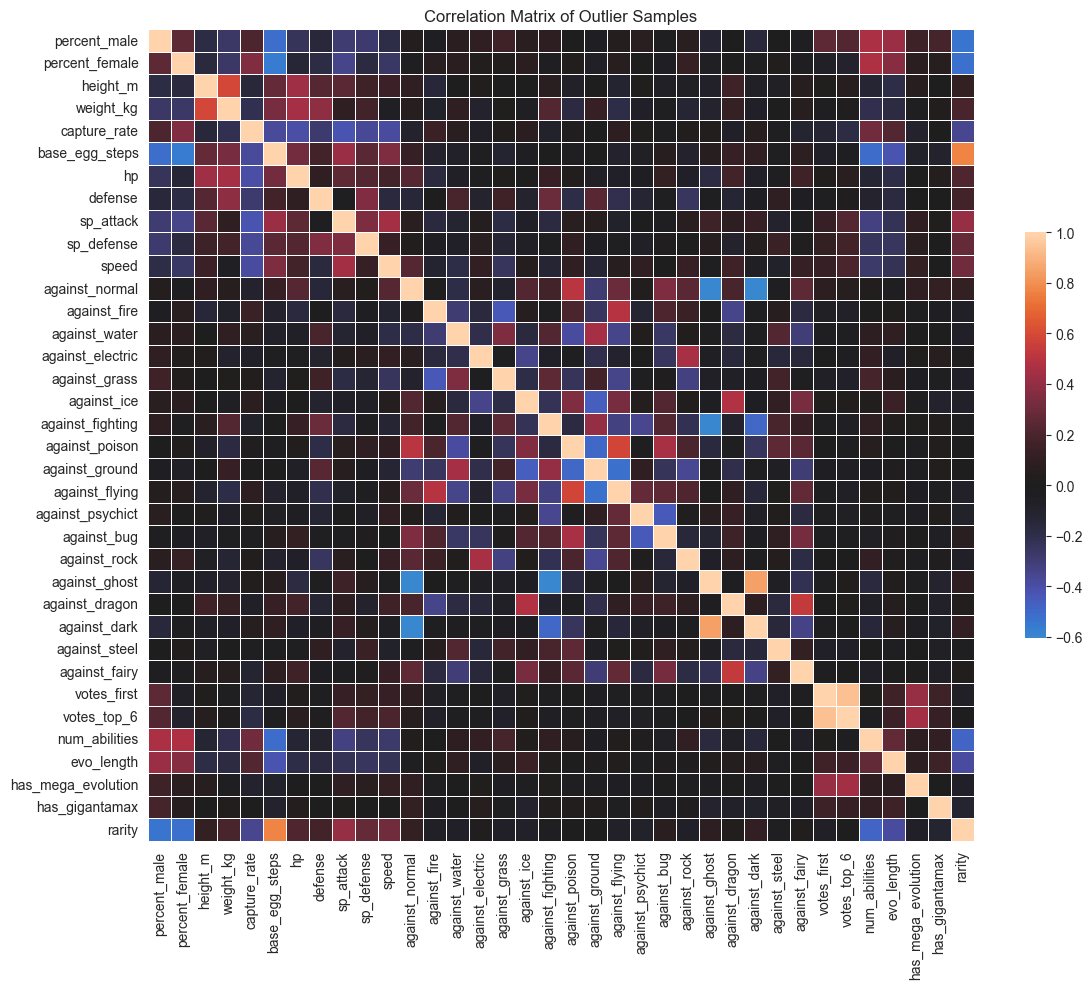

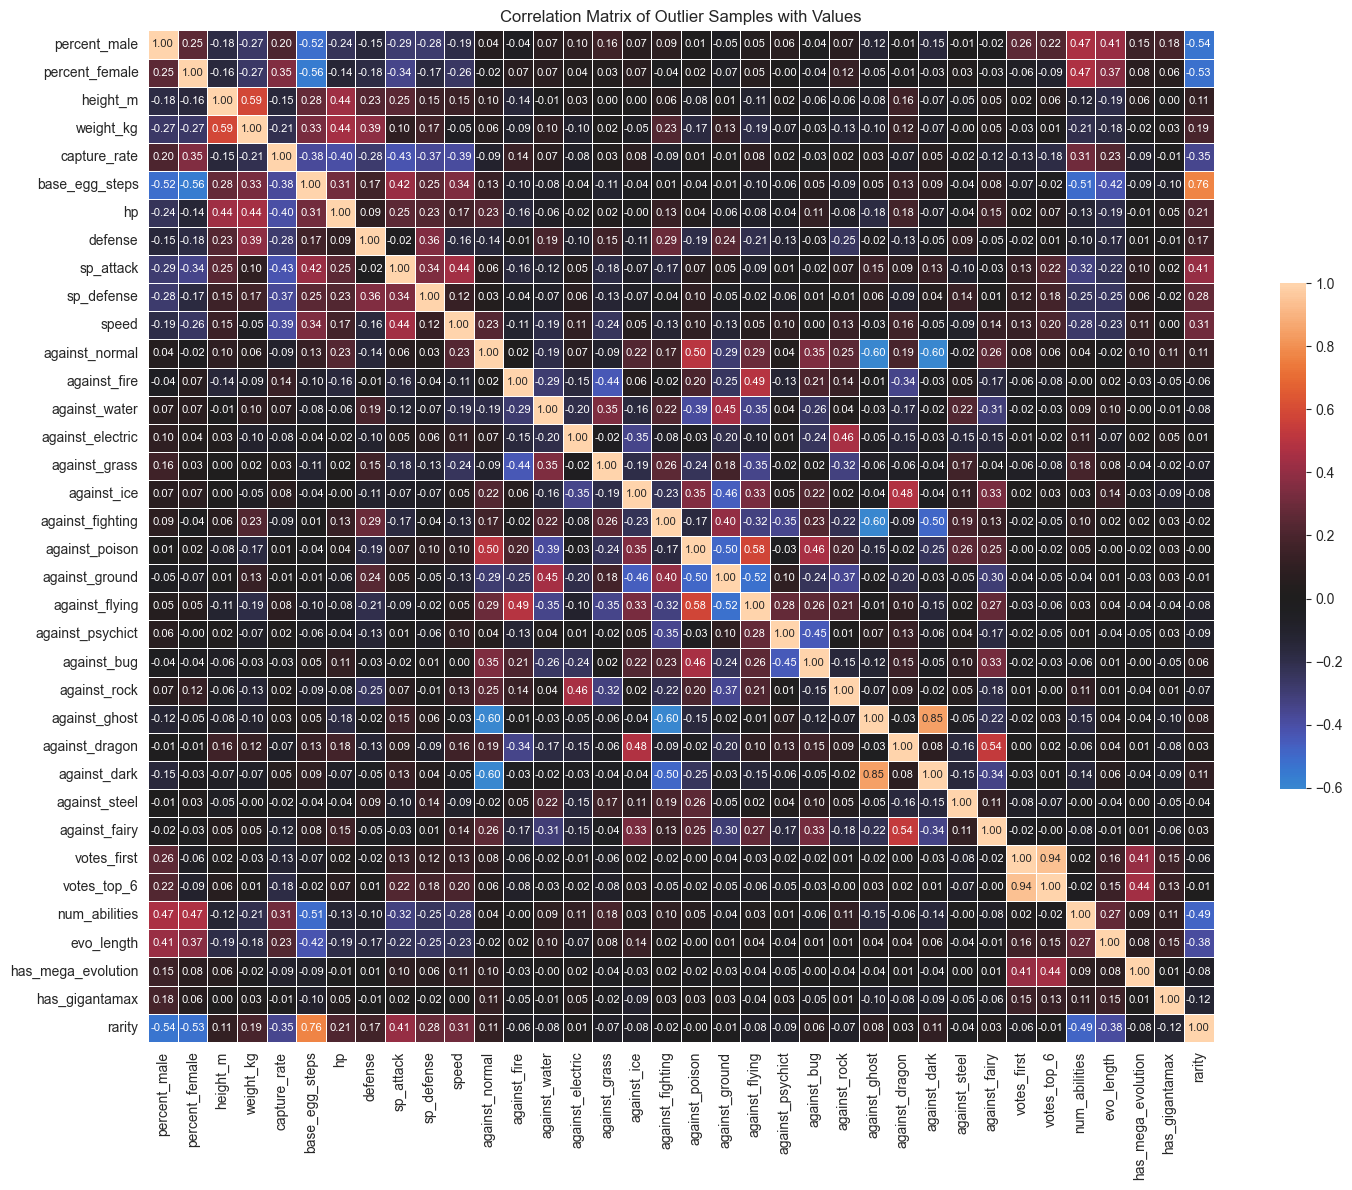

In [65]:
# Correlation heatmap of features for outlier samples
outlier_data = data_df[outliers]
outlier_features = outlier_data[feature_cols]
corr_matrix = outlier_features.corr()
plt.figure(figsize=(12, 10))
sns.color_palette("rocket")
sns.heatmap(corr_matrix, center=0, annot=False, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink": .5})
plt.title("Correlation Matrix of Outlier Samples")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Let's add the actual values into the heatmap
# Make sure to make the figure larger for better readability
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, center=0, annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink": .5}, annot_kws={"size": 8})
plt.title("Correlation Matrix of Outlier Samples with Values")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [66]:
# Let's enumerate the most interesting correlations among outlier features
abs_corr = corr_matrix.abs()
pairs = (
    abs_corr.unstack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'abs_corr'})
)
pairs = pairs[pairs['var1'] != pairs['var2']]
# keep unique pairs (unordered) and sort by absolute correlation
pairs['pair_key'] = pairs.apply(lambda r: tuple(sorted((r['var1'], r['var2']))), axis=1)
top_pairs = pairs.drop_duplicates(subset='pair_key').sort_values('abs_corr', ascending=False)

In [67]:
top_pairs.head(20)

,var1,var2,abs_corr,pair_key
1074,votes_first,votes_top_6,0.939382,"(votes_first, votes_top_6)"
890,against_ghost,against_dark,0.849564,"(against_dark, against_ghost)"
215,base_egg_steps,rarity,0.761986,"(base_egg_steps, rarity)"
420,against_normal,against_ghost,0.604078,"(against_ghost, against_normal)"
636,against_fighting,against_ghost,0.598342,"(against_fighting, against_ghost)"
422,against_normal,against_dark,0.598283,"(against_dark, against_normal)"
75,height_m,weight_kg,0.587023,"(height_m, weight_kg)"
668,against_poison,against_flying,0.575488,"(against_flying, against_poison)"
41,percent_female,base_egg_steps,0.563860,"(base_egg_steps, percent_female)"
35,percent_male,rarity,0.539499,"(percent_male, rarity)"


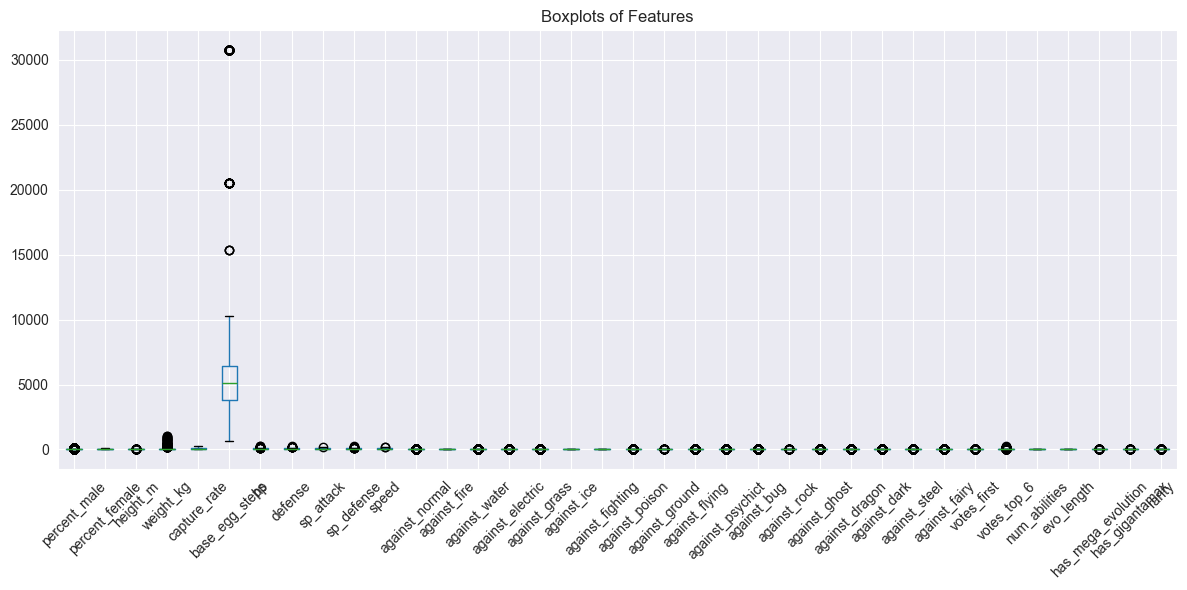

In [68]:
# Boxplots and histograms


plt.figure(figsize=(12, 6))
data_df[feature_cols].boxplot()
plt.title("Boxplots of Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
# Histograms of features

# fig, axes = plt.subplots(nrows=len(feature_cols), ncols=1, figsize=(10, 5 * len(feature_cols)))
# for ax, col in zip(axes, feature_cols):
#     sns.histplot(data_df[col], bins=30, kde=True, ax=ax)
#     ax.set_title(f"Histogram of {col}")
# plt.tight_layout()
# plt.show()

In [70]:
# Highlight pokemns with many outlier features in these distributions

threshold = data_df['num_outlier_features'].quantile(0.95)  # top 5% as high outlier count
high_outlier_data = data_df[data_df['num_outlier_features'] >= threshold].sort_values(by='num_outlier_features', ascending=False)

print("Pokemons with high number of outlier features:")
print(f"(Threshold: {threshold} outlier features)")
display(high_outlier_data[['english_name', 'num_outlier_features'] + feature_cols].reset_index(drop=True))

Pokemons with high number of outlier features:
(Threshold: 2.0 outlier features)


,english_name,num_outlier_features,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,defense,...,against_dark,against_steel,against_fairy,votes_first,votes_top_6,num_abilities,evo_length,has_mega_evolution,has_gigantamax,rarity
0,Rayquaza,6,0.00,0.00,7.0,206.5,45.0,30720.0,105.0,90.0,...,1.0,1.0,2.0,20.0,156.0,1.0,1.0,1.0,0.0,2.0
1,Stakataka,6,0.00,0.00,5.5,820.0,30.0,30720.0,61.0,211.0,...,1.0,1.0,0.5,0.0,8.0,1.0,1.0,0.0,0.0,1.0
2,Lunala,5,0.00,0.00,4.0,120.0,45.0,30720.0,137.0,89.0,...,4.0,1.0,1.0,2.0,24.0,1.0,7.0,0.0,0.0,2.0
3,Charizard,5,88.14,11.86,1.7,90.5,45.0,5120.0,78.0,78.0,...,1.0,0.5,0.5,69.0,248.0,2.0,5.0,1.0,1.0,0.0
4,Snorlax,5,88.14,11.86,2.1,460.0,25.0,10240.0,160.0,65.0,...,1.0,1.0,1.0,29.0,98.0,3.0,3.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,Jirachi,2,0.00,0.00,0.3,1.1,3.0,30720.0,100.0,100.0,...,2.0,0.5,0.5,7.0,46.0,1.0,1.0,0.0,0.0,3.0
137,Kyogre,2,0.00,0.00,4.5,352.0,3.0,30720.0,100.0,90.0,...,1.0,0.5,1.0,5.0,39.0,1.0,1.0,0.0,0.0,2.0
138,Latios,2,100.00,0.00,2.0,60.0,3.0,30720.0,80.0,80.0,...,2.0,1.0,2.0,4.0,29.0,1.0,1.0,1.0,0.0,1.0
139,Latias,2,0.00,100.00,1.4,40.0,3.0,30720.0,80.0,90.0,...,2.0,1.0,2.0,5.0,34.0,1.0,1.0,1.0,0.0,1.0


In [71]:
# Lets print count plot of top 20 pokemons with highest outlier features by their primary class

# plt.figure(figsize=(12, 6))
# sns.countplot(data=high_outlier_data.head(20), x='class_primary', order=high_outlier_data['class_primary'].value_counts().index)
#
# plt.title("Primary Class Distribution of Top 20 Pokemons with Highest Outlier Features")
# plt.xlabel("Primary Class")
# plt.ylabel("Count")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()
#
# plt.figure(figsize=(12, 6))
# sns.countplot(data=high_outlier_data.head(20), x='gen', order=high_outlier_data['gen'].value_counts().index)
# plt.title("Primary Class Distribution of Top 20 Pokemons with Highest Outlier Features")
# plt.xlabel("Generation")
# plt.ylabel("Count")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()



In [72]:
def scatter_with_outliers(df, x_col, y_col, outlier_mask, annotate=True):
    plt.figure(figsize=(10, 6))
    plt.scatter(df[~outlier_mask][x_col], df[~outlier_mask][y_col], label='Normal Data', alpha=0.4)
    plt.scatter(df[outlier_mask][x_col], df[outlier_mask][y_col], color='red', label='Outliers', alpha=0.7)

    # Annotate outlier points
    if annotate:
        for _, row in df[outlier_mask].iterrows():
            plt.annotate(row['english_name'], (row[x_col], row[y_col]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'Scatter Plot of {y_col} vs {x_col} with Outliers Highlighted')
    plt.legend()
    plt.grid(True)
    plt.show()

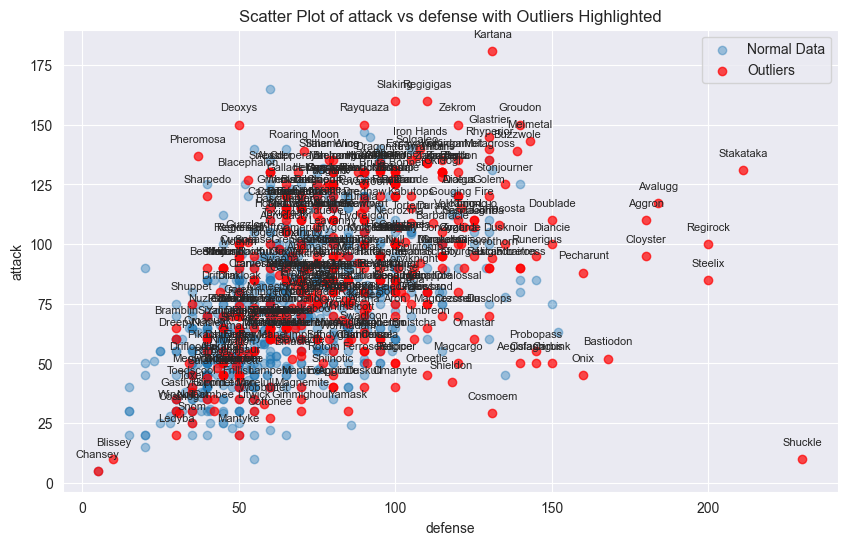

In [73]:
scatter_with_outliers(data_df, 'defense', 'attack', outliers, annotate=True)
#scatter_with_outliers(data_df, 'defense', 'attack', outliers, annotate=False)

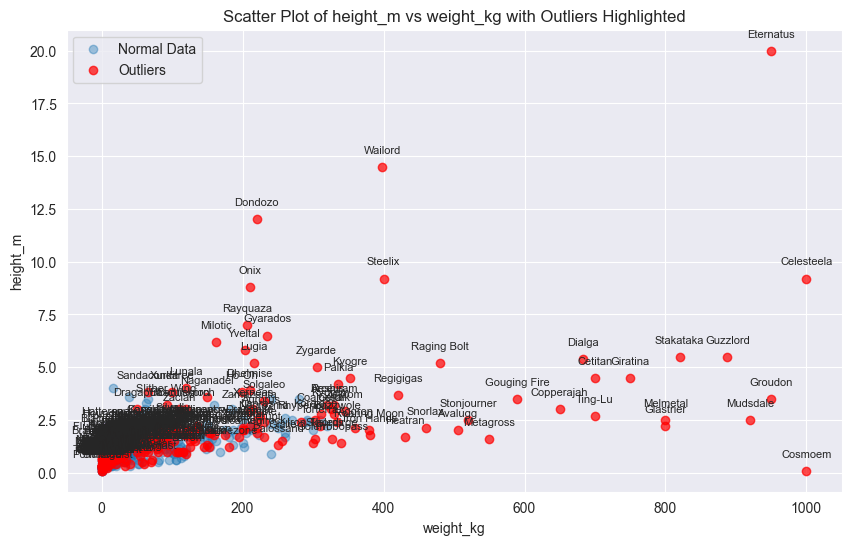

In [74]:
scatter_with_outliers(data_df, 'weight_kg', 'height_m', outliers, annotate=True)
#scatter_with_outliers(data_df, 'weight_kg', 'height_m', outliers, annotate=False)

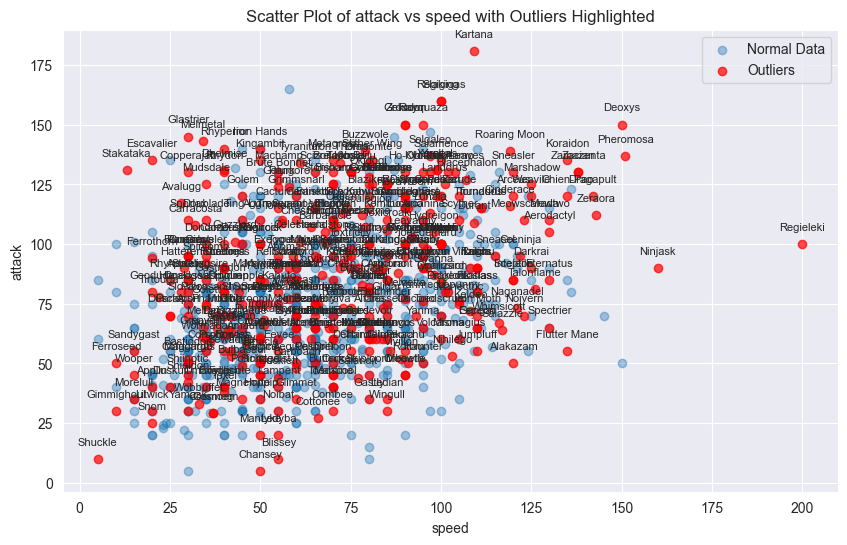

In [75]:
scatter_with_outliers(data_df, 'speed', 'attack', outliers, annotate=True)

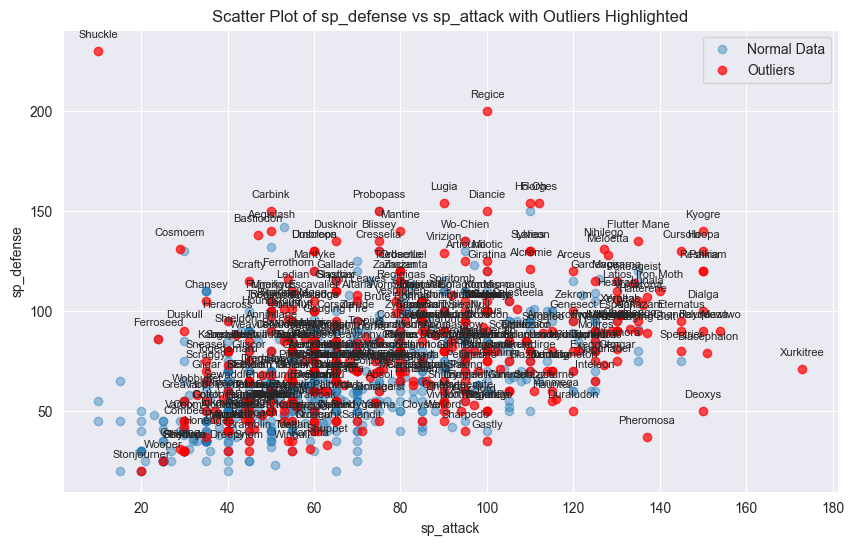

In [76]:
scatter_with_outliers(data_df, 'sp_attack', 'sp_defense', outliers, annotate=True)

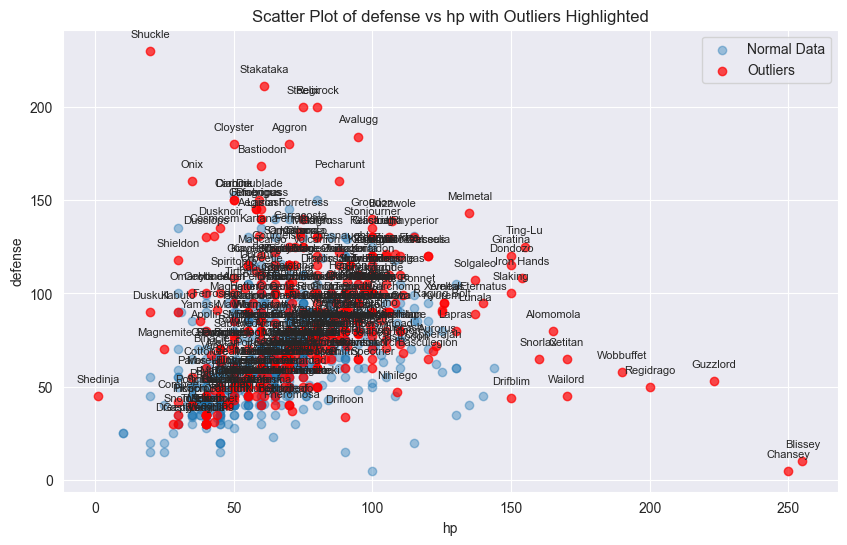

In [77]:
scatter_with_outliers(data_df, 'hp', 'defense', outliers, annotate=True)

In [78]:
# display scatter plots with top correlated feature pairs among outliers

# for _, row in top_pairs.head(10).iterrows():
#     scatter_with_outliers(data_df, row['var1'], row['var2'], outliers, annotate=True)

## Multivariate anomalies ##


In [79]:
import sklearn
from sklearn.preprocessing import StandardScaler

In [80]:
num_cols = [c for c in data_df.select_dtypes(include=[np.number]).columns if c in feature_cols]
X = data_df[num_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [113]:
def visualize_score_distribution(score_column, title):
    plt.figure(figsize=(8, 4))
    sns.histplot(data_df[score_column], bins=40, kde=True)
    plt.title(title)
    plt.xlabel("Score")
    plt.grid(True)
    plt.show()

def plot_decision_function_2d(score_column, title, anomaly_flag_col=None, annotate=True):
    plt.figure(figsize=(9, 7))

    # Sort: anomalies on top
    df_sorted = data_df.sort_values(score_column)

    scatter = plt.scatter(
        df_sorted["pca_vis_1"],
        df_sorted["pca_vis_2"],
        c=df_sorted[score_column],
        cmap="viridis",
        alpha=0.7
    )

    plt.colorbar(scatter, label=score_column)
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid(True)

    if anomaly_flag_col is not None:
        anomalies = data_df[data_df[anomaly_flag_col]]

        # Highlight anomalies
        plt.scatter(
            anomalies["pca_vis_1"],
            anomalies["pca_vis_2"],
            color="red",
            s=60,
            edgecolor="black",
            label="Detected Anomaly"
        )

        # Add annotations
        if annotate:
            for _, row in anomalies.iterrows():
                plt.annotate(
                    row["english_name"],
                    (row["pca_vis_1"], row["pca_vis_2"]),
                    fontsize=6,
                    xytext=(3, 3),
                    textcoords="offset points"
                )

        plt.legend()
    plt.show()

def plot_score_with_anomalies(score_column, anomaly_flag_col, title):
    plt.figure(figsize=(8, 4))
    sns.histplot(data_df[score_column], bins=40, kde=True, color="gray")

    # overlay anomalies
    anomaly_scores = data_df.loc[data_df[anomaly_flag_col], score_column]
    plt.scatter(anomaly_scores, np.zeros_like(anomaly_scores),
                color="red", label="Anomalies", s=40)

    plt.title(title)
    plt.legend()
    plt.show()



### Isolation Forest ###

In [82]:
 # anomaly detection with isolation forest
from sklearn.ensemble import IsolationForest

In [83]:
# add a column to the original dataframe to keep track of anomalies detected by isolation forests

iso = IsolationForest(n_estimators=300,
                      contamination=0.05,
                      random_state=42)

iso_pred = iso.fit_predict(X_scaled)
iso_score = iso.decision_function(X_scaled)

data_df["anomaly_if"] = (iso_pred == -1)
data_df["iforest_score"] = iso_score

In [84]:
# Let's see the results

outliers_if_df = data_df[data_df["anomaly_if"] == True]

outliers_if_df

,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,num_abilities,evo_length,has_mega_evolution,has_gigantamax,rarity,class_primary,class_secondary,num_outlier_features,anomaly_if,iforest_score
5,1.0,Charizard,88.14,11.86,1.7,90.5,45.0,5120.0,78.0,84.0,...,2.0,5.0,1.0,1.0,0.0,1,2,5,True,-0.069492
93,1.0,Gengar,50.20,49.80,1.5,40.5,45.0,5120.0,60.0,65.0,...,1.0,5.0,1.0,1.0,0.0,12,0,5,True,-0.079460
94,1.0,Onix,50.20,49.80,8.8,210.0,45.0,6400.0,35.0,45.0,...,3.0,3.0,0.0,0.0,0.0,11,6,3,True,-0.026622
149,1.0,Mewtwo,0.00,0.00,2.0,122.0,3.0,30720.0,106.0,110.0,...,2.0,1.0,1.0,0.0,2.0,10,1,4,True,-0.028981
150,1.0,Mew,0.00,0.00,0.4,4.0,45.0,30720.0,100.0,100.0,...,1.0,1.0,0.0,0.0,3.0,10,1,3,True,-0.001035
207,2.0,Steelix,50.20,49.80,9.2,400.0,25.0,6400.0,75.0,85.0,...,3.0,3.0,1.0,0.0,0.0,16,6,3,True,-0.029184
247,2.0,Tyranitar,50.20,49.80,2.0,202.0,45.0,10240.0,100.0,134.0,...,2.0,5.0,1.0,0.0,0.0,11,3,4,True,-0.053974
248,2.0,Lugia,0.00,0.00,5.2,216.0,3.0,30720.0,106.0,90.0,...,2.0,1.0,0.0,0.0,2.0,10,2,4,True,-0.041659
249,2.0,Ho-Oh,0.00,0.00,3.8,199.0,3.0,30720.0,106.0,130.0,...,2.0,1.0,0.0,0.0,2.0,1,2,4,True,-0.021853
250,2.0,Celebi,0.00,0.00,0.6,5.0,45.0,30720.0,100.0,100.0,...,1.0,1.0,0.0,0.0,3.0,10,8,3,True,-0.027275


In [85]:
len(outliers_if_df)

52

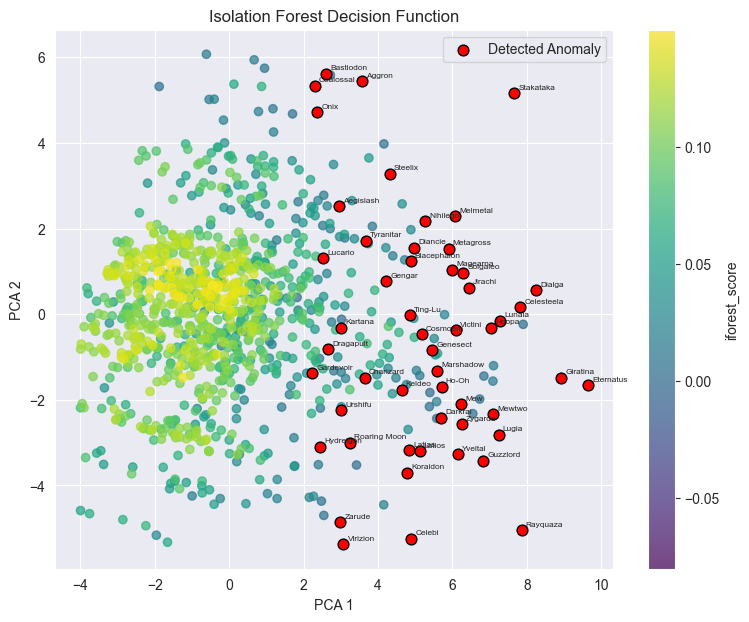

In [89]:
# visualize_score_distribution("iforest_score", "Isolation Forest Score Distribution")
# scatter_with_outliers(data_df, 'weight_kg', 'height_m', data_df["anomaly_if"], annotate=True)
# scatter_with_outliers(data_df, 'hp', 'defense', data_df["anomaly_if"], annotate=True)

plot_decision_function_2d(
    score_column="iforest_score",
    title="Isolation Forest Decision Function",
    anomaly_flag_col="anomaly_if",
    annotate=True
)


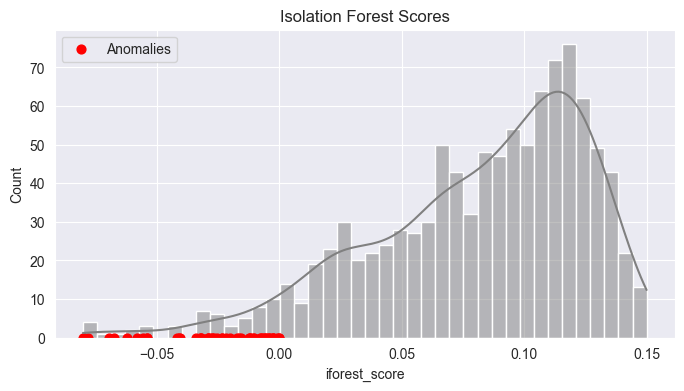

In [114]:
plot_score_with_anomalies("iforest_score", "anomaly_if", "Isolation Forest Scores")

## Local Outlier Factor ##

In [90]:
from sklearn.neighbors import LocalOutlierFactor

In [91]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=False
)

lof_pred = lof.fit_predict(X_scaled) # -1 = anomaly, 1 = normal
lof_score = lof.negative_outlier_factor_ # more negative = more abnormal

data_df["anomaly_lof"] = (lof_pred == -1)
data_df["lof_score"] = lof_score

In [92]:
len(data_df[data_df["anomaly_lof"] == True])

52

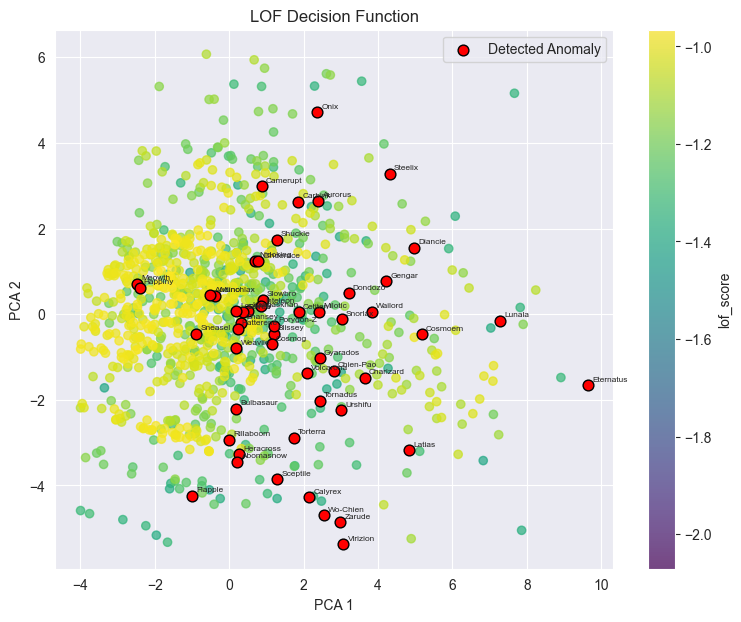

In [94]:

plot_decision_function_2d(
    score_column="lof_score",
    title="LOF Decision Function",
    anomaly_flag_col="anomaly_lof",
    annotate=True
)


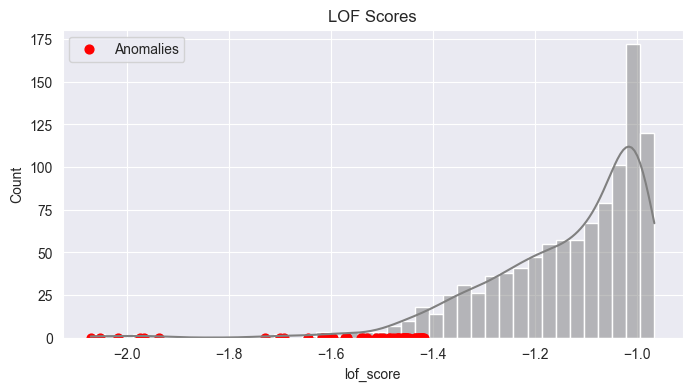

In [115]:
plot_score_with_anomalies("lof_score", "anomaly_lof", "LOF Scores")

## PCA anomaly score ##

In [100]:
from sklearn.decomposition import PCA

In [101]:
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)

pca_dist = np.linalg.norm(X_pca, axis=1)

pca_contamination = 0.05
pca_threshold = np.quantile(pca_dist, 1 - pca_contamination)

data_df["pca_dist"] = pca_dist
data_df["anomaly_pca"] = pca_dist > pca_threshold

In [112]:
# len(data_df["anomaly_pca"] == True)
print(len(data_df[data_df["anomaly_pca"] == True]))
print(len(data_df[data_df["anomaly_pca"] == False]))


52
972


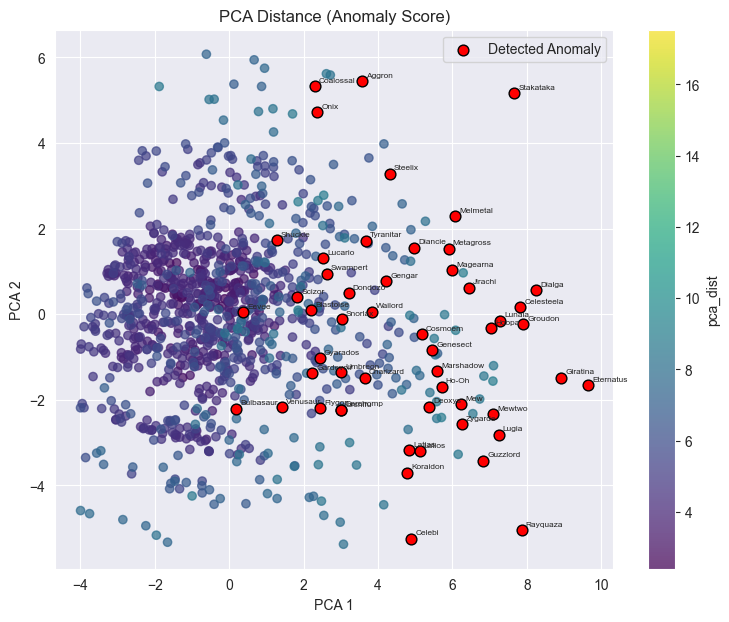

In [103]:
plot_decision_function_2d(
    score_column="pca_dist",
    title="PCA Distance (Anomaly Score)",
    anomaly_flag_col="anomaly_pca"
)


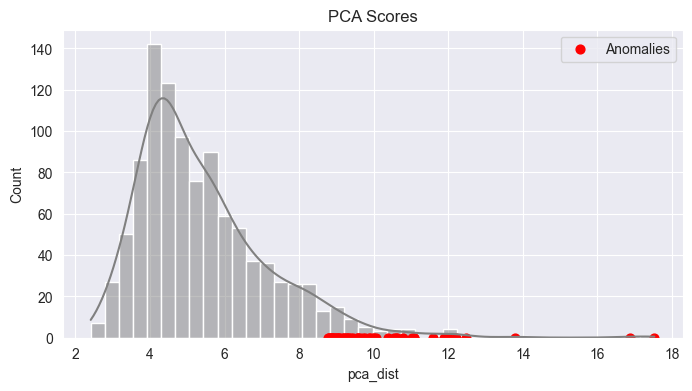

In [116]:
plot_score_with_anomalies("pca_dist", "anomaly_pca", "PCA Scores")

## One Class SVM ##

In [96]:
from sklearn.svm import OneClassSVM



In [97]:
ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="auto",
    nu=0.05
)

ocsvm.fit(X_scaled)
ocsvm_pred = ocsvm.predict(X_scaled)         # -1 = anomaly, 1 = normal
ocsvm_score = ocsvm.decision_function(X_scaled)  # higher = more normal

data_df["anomaly_ocsvm"] = (ocsvm_pred == -1)
data_df["ocsvm_score"] = ocsvm_score


In [98]:
len(data_df["ocsvm_score"] == True)

1024

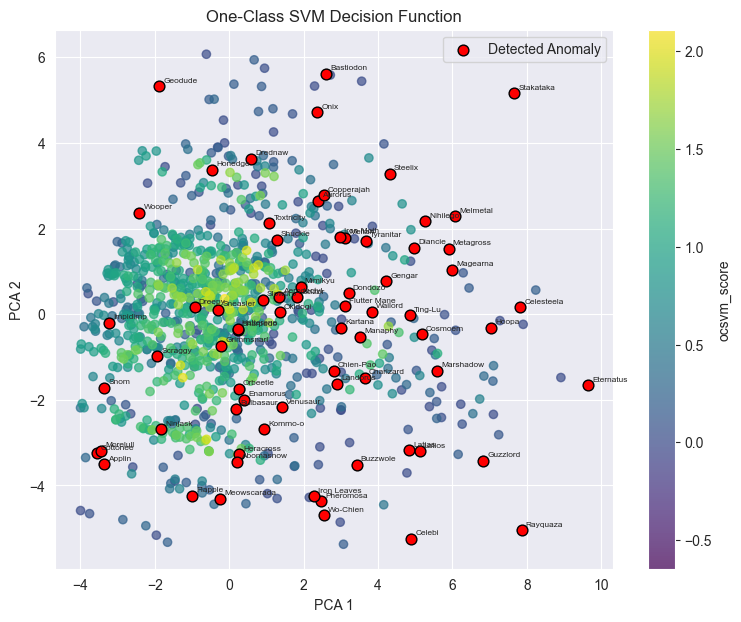

In [99]:
plot_decision_function_2d(
    score_column="ocsvm_score",
    title="One-Class SVM Decision Function",
    anomaly_flag_col="anomaly_ocsvm",
    annotate=True
)


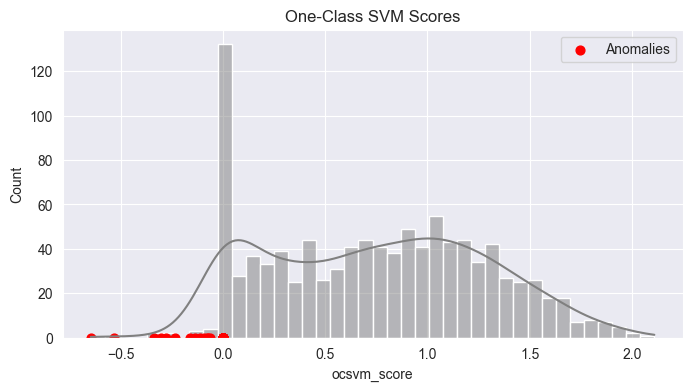

In [117]:
plot_score_with_anomalies("ocsvm_score", "anomaly_ocsvm", "One-Class SVM Scores")

## All classifiers in one ##


In [88]:
# Compute 2D PCA for visualization (independent of your PCA anomaly detector)
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)

data_df["pca_vis_1"] = X_vis[:, 0]
data_df["pca_vis_2"] = X_vis[:, 1]


In [118]:
classif_cols = [
    "anomaly_if",
    "anomaly_lof",
    "anomaly_pca",
    "anomaly_ocsvm"
]

# save fired anomalies from each method
data_df["anomaly_fired"] = data_df[classif_cols].sum(axis=1)
data_df["anomaly_any"] = data_df[classif_cols].any(axis=1)

# classified as an anomaly by at least N methods
classif_threshold = 3

data_df["anomaly_strong"] = data_df["anomaly_fired"] > classif_threshold

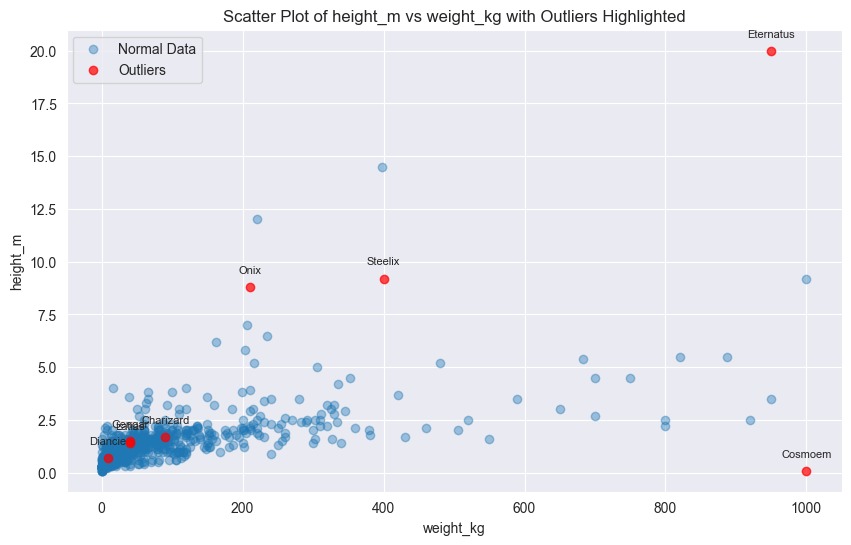

In [123]:
highlight_mask = data_df["anomaly_strong"]
scatter_with_outliers(data_df, 'weight_kg', 'height_m', highlight_mask, annotate=True)
